# Lab 1: 実機ハードウェア向けの量子回路を構築する

## Qiskit Global Summer School 2026

Lab 1 へようこそ！このノートブックでは、量子回路をゼロから構築し、実際の量子ハードウェア上で実行できるように準備する方法を学びます。

**学ぶこと:**

1. [**パート1: 基本ゲートと量子の概念**](#part1): X、H、CX ゲートがどのように重ね合わせと量子もつれを生み出すか
2. [**パート2: 回路の深さ**](#part2): なぜ深さが重要なのか、GHZ 状態、そして対称性を使って深さを減らす方法
3. [**パート3: トランスパイル**](#part3): 実機プロセッサー（133量子ビットの IBM Heron チップ）の制約に回路を適合させる
4. [**パート4: ノイズ入りシミュレーターで実行する**](#part4): ノイズ入りシミュレーターで回路を実行し、結果を比較する

各パートは前のパートの上に積み重なっており、最後には実機向けに効率的な64量子ビットのもつれ状態を構築できるようになります。これらのスキルは Lab 2 に直接つながります。

## 始める前に

> **このラボは全体がローカルの *シミュレーター*（`FakeTorino`）で動作します。** ここでは IBM Quantum のランタイム時間（分）を **一切** 消費しません。すべての回路はローカルでトランスパイルされ、実行されます。（パート4の最後で、実機バックエンドを指定する方法を示します。）ただし、grader に解答を提出するには設定済みの IBM Quantum アカウントが *必要* です。採点セルで認証エラーが出た場合は、インポートのすぐ下にあるアカウント設定セルを参照してください。

<details>
<summary><b>よくあるセットアップの問題（クリックで展開）</b></summary>

- **図が表示されない？** **VS Code** を使っていて、プロットが描画されずテキストとして表示される場合は、セルを再実行してください。このノートブックは `display(...)` を明示的に呼び出しているので、Jupyter、JupyterLab、VS Code、Colab、qBraid のいずれでも図が表示されます。
- **`jupyter notebook` が見つからない？** 代わりに **JupyterLab** がインストールされているかもしれません。`jupyter lab` で起動してください。
- **トポロジー／ゲートマップのプロットで Graphviz のエラーが出る？** Graphviz をインストールしてください（`conda install -c conda-forge python-graphviz`、またはお使いの OS のパッケージマネージャー）。このラボのトポロジープロットは `networkx` + `matplotlib` を使うので、ほとんどのユーザーには不要です。
- **`pip` が間違った環境にインストールしてしまう？** `!pip` ではなく（下のインストールセルのように）`%pip` マジックを使ってください。`%pip` は常に実行中のカーネルを対象とします。

</details>

**役立つ Qiskit ドキュメント:** [回路とゲート](https://quantum.cloud.ibm.com/docs/api/qiskit/circuit) · [`QuantumCircuit`](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.QuantumCircuit) · [トランスパイル](https://docs.quantum.ibm.com/guides/transpile) · [`Statevector`](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.Statevector)

## インポート

In [1]:
# これらのパッケージが環境にまだインストールされていない場合は、このセルを実行してください。
# (%pip マジックを使うことで、パッケージは常に *実行中の* カーネルにインストールされます。
#  素の !pip が間違った環境を対象にしうる qBraid/Colab では重要です。)
%pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer numpy networkx
%pip install --upgrade qc-grader


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np

print("インポートが正常に読み込まれました — 準備完了です。")

インポートが正常に読み込まれました — 準備完了です。


In [3]:
from qc_grader.challenges.qgss_2026 import (
    grade_lab1_ex1,
    grade_lab1_ex2,
    grade_lab1_ex3,
    grade_lab1_ex4,
    grade_lab1_ex5,
    grade_lab1_ex6,
    grade_lab1_ex7,
)

In [4]:
# ── (任意) IBM Quantum アカウントのセットアップ ──────────────────────────────────
# grader は解答をローカルで確認しますが、それを *提出* するには設定済みの
# IBM Quantum アカウントが必要です。新しい Colab/qBraid セッションは、Lab 0 で
# 保存したアカウントを引き継ぎません。そのため、下の採点セルが認証エラーで
# 失敗する場合は、Lab 0 で使ったのと同じ save_account(...) 呼び出しを実行してください。
# 例えば:
#
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="NbPlnHvdQMjaS0yCbd_9dCQ1OIxrcKa2XQLnNeSqzElN",
    overwrite=True,
)

#これは環境ごとに一度だけ行えば十分です。

---

## パート1: 基本ゲートと量子の概念 <a id="part1"></a>

量子計算は、古典ビットの量子版である **量子ビット** を操作することで動作します。量子ビットは状態 $|0\rangle$ から始まり、それを **量子ゲート** を使って変換します。最も重要な単一量子ビットゲートと2量子ビットゲートの3つを見ていきましょう。

### X ゲート（ビット反転）

X ゲートは量子ビットの状態を反転させます。$|0\rangle \to |1\rangle$、$|1\rangle \to |0\rangle$ です。古典的な NOT ゲートの量子版です。

幾何学的には、X はブロッホ球の X 軸まわりの $\pi$（180°）回転です。その行列は次のとおりです。

$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

> **下の出力の読み方:** 各状態を2通りで示します。状態 *ベクトル*（LaTeX 形式。各項は $|0\rangle$ のような基底状態に掛かる振幅です）と、**ブロッホ球**（単一量子ビットの幾何学的な描像）です。基底状態の測定確率は、その振幅の絶対値の2乗です。

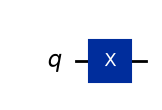

<IPython.core.display.Latex object>

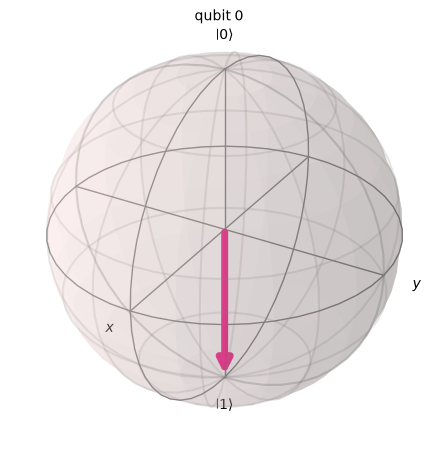

In [5]:
# 単一量子ビットに X ゲートを適用する回路を構築
qc = QuantumCircuit(1)
qc.x(0)
display(qc.draw("mpl"))

# 得られた状態を確認: ベクトルとして (LaTeX)、そしてブロッホ球上で
sv = Statevector(qc)
display(sv.draw("latex"))
display(plot_bloch_multivector(sv))

### H ゲート（重ね合わせ）

アダマールゲートは量子ビットを **重ね合わせ** にします。これは、同時に一部が $|0\rangle$、一部が $|1\rangle$ である状態です。

$$H|0\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)$$

この状態の量子ビットを測定すると、$|0\rangle$ または $|1\rangle$ がそれぞれ 50% の確率で得られます。X と同様に H ゲートも回転で、今回はブロッホ球上で X 軸と Z 軸のちょうど中間にある軸まわりの $\pi$ 回転です。その行列は次のとおりです。

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

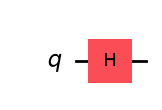

<IPython.core.display.Latex object>

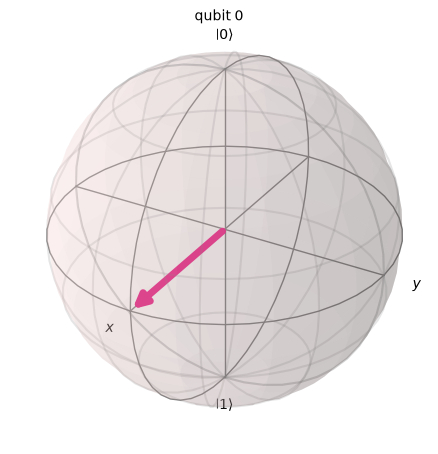

In [6]:
qc = QuantumCircuit(1)
qc.h(0)
display(qc.draw("mpl"))

sv = Statevector(qc)
display(sv.draw("latex"))
display(plot_bloch_multivector(sv))

### CX（CNOT）ゲートと量子もつれ

CX ゲートは **2量子ビット** ゲートです。**制御** 量子ビットが $|1\rangle$ のとき、かつそのときに限り **標的** 量子ビットを反転させます。制御が重ね合わせにあるとき、注目すべきことが起こります。2つの量子ビットが **もつれる** のです。それらの測定結果は、古典的には説明できないかたちで完全に相関するようになります。

最初の **ベル状態** を作って、これを実際に見てみましょう。

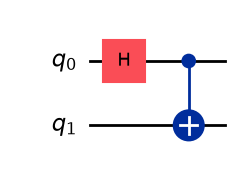

<IPython.core.display.Latex object>

In [7]:
# ベル状態 (|00⟩ + |11⟩) / √2 を作成
qc = QuantumCircuit(2)
qc.h(0)  # 量子ビット0を重ね合わせにする
qc.cx(0, 1)  # 量子ビット1を量子ビット0ともつれさせる
display(qc.draw("mpl"))

sv = Statevector(qc)
display(sv.draw("latex"))

#### ベル状態を理解する

今作った状態は $\frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr)$ です。これは何を意味するのでしょうか。

- 両方の量子ビットを測定すると、$|00\rangle$ または $|11\rangle$ がそれぞれ 50% の確率で得られます。
- $|01\rangle$ や $|10\rangle$ は **決して** 得られません。量子ビットは完全に相関しています。
- この相関は、量子ビットがどれだけ離れていても持続します。これが **量子もつれ** であり、量子計算を強力にする鍵となるリソースです。

### 演習1: $|01\rangle + |10\rangle$ のベル状態を構築する

先ほど $\frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr)$ を構築しました。今度はあなたの番です！

**課題:** ベル状態 $\frac{1}{\sqrt{2}}\bigl(|01\rangle + |10\rangle\bigr)$ を準備する回路を構築してください。

<details>
<summary><b>ヒント</b></summary>

$|00\rangle + |11\rangle$ の作り方はもう知っています。片方の量子ビットを反転させるには、どのゲートを1つ追加すればよいでしょうか。
</details>

ドキュメント: [`QuantumCircuit` のゲート](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit)（`.x()`、`.h()`、`.cx()` を参照）

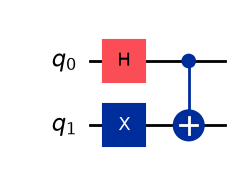

<IPython.core.display.Latex object>

In [9]:
qc = QuantumCircuit(2)

## ここにあなたのコードを追加してください ##

qc.h(0)
qc.x(1)
qc.cx(0,1)
## 解答を確認
display(qc.draw("mpl"))
sv = Statevector(qc)
display(sv.draw("latex"))

In [10]:
grade_lab1_ex1(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 06:43:33,793: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! Your circuit produces (|01⟩ + |10⟩) / √2 (fidelity 1.0000).
You scored 1 on this exercise.


#### 同じ状態への複数の道すじ

量子回路の美しい点の一つは、同じ状態がしばしば異なる方法で準備できることです。$|01\rangle + |10\rangle$ を構築する方法は（少なくとも）3通りあります。

<details>
<summary><b>クリックして3つの解答をすべて表示</b></summary>

**方法1:** ベル回路の *前* に X を適用する:

```python
qc = QuantumCircuit(2)
qc.x(1)        # 先に量子ビット1を |1⟩ に反転
qc.h(0)
qc.cx(0, 1)
```

**方法2:** ベル回路の *後* に量子ビット1へ X を適用する:

```python
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)        # もつれさせた後に量子ビット1を反転
```

**方法3:** ベル回路の *後* に量子ビット0へ X を適用する:

```python
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(0)        # もつれさせた後に量子ビット0を反転
```

3つとも同じ状態を生成します！これは意外に思えるかもしれません。特に、量子ビット1ではなく量子ビット0を反転させる方法3はそうです。しかし量子ビットがもつれているため、*どちらか* 一方を反転させると $|00\rangle \leftrightarrow |01\rangle$ と $|11\rangle \leftrightarrow |10\rangle$ が入れ替わり、どちらの場合も $|01\rangle + |10\rangle$ が得られます。

この考え方（同じ量子状態が異なる回路で到達できること）は、実機向けの最適化を始めるときに重要になります。
</details>

### 任意: 相対位相

ここまで $|00\rangle + |11\rangle$ と $|01\rangle + |10\rangle$ を見てきました。しかし実はベル状態は **4つ** あります。残りの2つには **マイナス符号**（相対位相）が含まれます。

$$\frac{1}{\sqrt{2}}\bigl(|00\rangle - |11\rangle\bigr) \qquad \text{および} \qquad \frac{1}{\sqrt{2}}\bigl(|01\rangle - |10\rangle\bigr)$$

**Z ゲート** はこの位相を導入します。$|0\rangle$ はそのままにし、$|1\rangle \to -|1\rangle$ に写します。

$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

このマイナス符号は標準基底での測定確率を変えません（依然として 50/50 になります）が、物理的には実在し、その後の計算での状態の干渉のしかたに影響します。

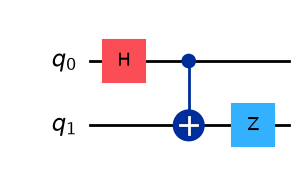

<IPython.core.display.Latex object>

In [12]:
# Z ゲートを追加して |00⟩ - |11⟩ を作成
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.z(1)  # qc.z(1) に変えてみてください -- 同じ結果になります！
display(qc.draw("mpl"))

sv = Statevector(qc)
display(sv.draw("latex"))

**任意の発展演習:** $\frac{1}{\sqrt{2}}\bigl(|01\rangle - |10\rangle\bigr)$ を構築できますか？ X ゲートと Z ゲートについて学んだことを組み合わせてみてください。（解答は用意していません。試してみましょう！）

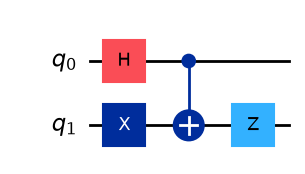

<IPython.core.display.Latex object>

In [15]:
qc = QuantumCircuit(2)

## ここにあなたのコードを追加してください ##

qc.h(0)
qc.x(1)
qc.cx(0,1)
qc.z(1)
## 確認
display(qc.draw("mpl"))
sv = Statevector(qc)
display(sv.draw("latex"))

### パート1のまとめ

**達成した学習目標:**
- **X ゲート**: $|0\rangle \leftrightarrow |1\rangle$ を反転（ビット反転 / X 軸まわりの $\pi$ 回転）
- **H ゲート**: 重ね合わせ $|0\rangle \to \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ を生成
- **CX ゲート**: 2つの量子ビットをもつれさせる、量子的優位性への鍵
- 同じ量子状態は **複数の異なる回路** で準備できる
- *任意*: 相対位相（$\pm$ 符号）は物理的に意味を持つ

---

## パート2: 回路の深さ <a id="part2"></a>

実際の量子ハードウェアでは、すべてのゲートがわずかな誤差を持ち込みます。ゲートの層が多い回路ほど、より多くのノイズを蓄積し、より悪い結果を生みます。この層の数は **回路の深さ** と呼ばれ、それを減らすことは量子計算における最も重要な実践的スキルの一つです。

このパートでは、深さとは何かを学び、より大きなもつれ状態を構築し、**対称性** によって回路の深さを劇的に減らせることを発見します。

### GHZ 状態: 大規模な量子もつれ

ベル状態は2つの量子ビットをもつれさせます。**GHZ 状態**（Greenberger–Horne–Zeilinger）は、これを $N$ 量子ビットに一般化します。

$$|\text{GHZ}_N\rangle = \frac{1}{\sqrt{2}}\bigl(|00\ldots0\rangle + |11\ldots1\rangle\bigr)$$

3量子ビットの場合: $\frac{1}{\sqrt{2}}\bigl(|000\rangle + |111\rangle\bigr)$。測定すると、すべての量子ビットが一致します。すべて0か、すべて1のいずれかです。

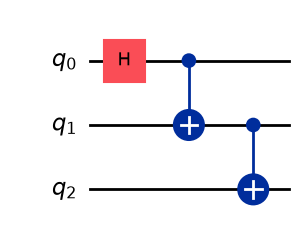

<IPython.core.display.Latex object>

In [16]:
# 3量子ビットの GHZ 状態
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
display(qc.draw("mpl"))

sv = Statevector(qc)
display(sv.draw("latex"))

### N 量子ビットの GHZ 状態を構築する2つの方法

GHZ 状態を構築する自然な方法は（少なくとも）2つあります。

1. **量子ビット0からのファンアウト**: 量子ビット0に H を適用し、次に量子ビット0から他のすべての量子ビットへ CX を適用します。CX(0,1)、CX(0,2)、…、CX(0,N−1)。
2. **隣接に沿ったチェーン**: 量子ビット0に H を適用し、次にもつれをチェーンに沿って伝えます。CX(0,1)、CX(1,2)、…、CX(N−2,N−1)。

どちらもまったく同じ GHZ 状態を生成します。再利用可能な関数として実装しましょう。

ファンアウト (5量子ビット):


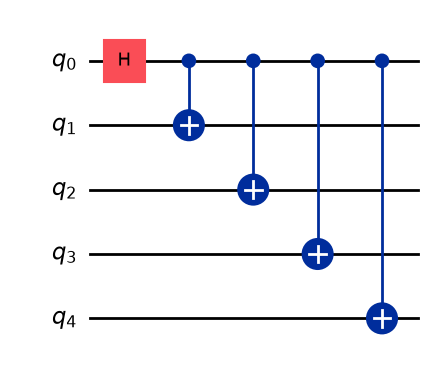


チェーン (5量子ビット):


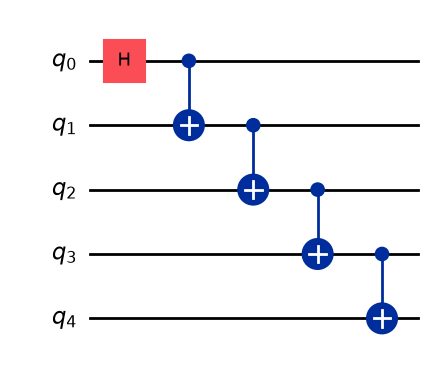

In [17]:
def ghz_fan(n):
    """ファンアウトによる GHZ: すべての CX ゲートが量子ビット0を制御として使う。"""
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(1, n):
        qc.cx(0, i)
    return qc


def ghz_chain(n):
    """チェーンによる GHZ: 各 CX がもつれを次の量子ビットへ渡す。"""
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)
    return qc


print("ファンアウト (5量子ビット):")
display(ghz_fan(5).draw("mpl"))
print("\nチェーン (5量子ビット):")
display(ghz_chain(5).draw("mpl"))

### 回路の深さとは何か？

量子回路の **深さ** は、できるだけ多くのゲートを **並列に** 実行すると仮定したときに、その回路を実行するのに必要な時間ステップ（層）の数です。

**並列化のルール:**
- 2つのゲートが **同じ層** で実行できるのは、それらが **完全に異なる量子ビット** に作用する場合だけです。
- 2つのゲートが量子ビットを1つでも共有する場合、それらは **異なる層** で実行しなければなりません。

> **注意:** 回路の見た目の描画は誤解を招くことがあります！図の上ではゲートが横並びに見えても、量子ビットを共有しているために順次実行になることがあります。深さが重要なときは、常にコードで確認してください。

独立した2つの X ゲート -- 深さ: 1


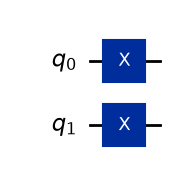


CX(0,1) の次に CX(0,2) -- 深さ: 2


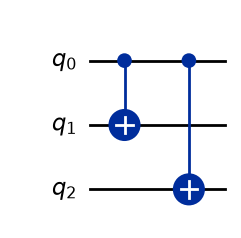


CX(0,1) と CX(2,3) を並列 -- 深さ: 1


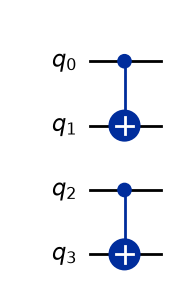

In [18]:
# 例1: 独立した2つの X ゲート → 深さ1（並列に実行される）
qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.x(1)
print("独立した2つの X ゲート -- 深さ:", qc1.depth())
display(qc1.draw("mpl"))

# 例2: 量子ビット0を共有する2つの CX ゲート → 深さ2（順次実行になる）
qc2 = QuantumCircuit(3)
qc2.cx(0, 1)
qc2.cx(0, 2)
print("\nCX(0,1) の次に CX(0,2) -- 深さ:", qc2.depth())
display(qc2.draw("mpl"))

# 例3: 互いに素な量子ビット上の2つの CX ゲート → 深さ1（並列）
qc3 = QuantumCircuit(4)
qc3.cx(0, 1)
qc3.cx(2, 3)
print("\nCX(0,1) と CX(2,3) を並列 -- 深さ:", qc3.depth())
display(qc3.draw("mpl"))

### 演習2: 回路の深さを予測する

下の回路を見て、チェックセルを実行する前に **その深さを予測** してください。どのゲートが並列に実行できるかを考えましょう。

次のセルで、印の付いた2行で `your_answer_a` と `your_answer_b` に予測した整数を設定し、チェックセルと grader を実行してください。

<details>
<summary><b>ヒント</b></summary>

各ゲートがどの量子ビットに触れるかを書き出して、層を割り出しましょう。2つのゲートが層を共有できるのは、完全に異なる量子ビットに作用する場合だけです。
</details>

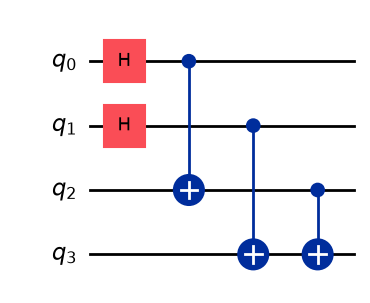

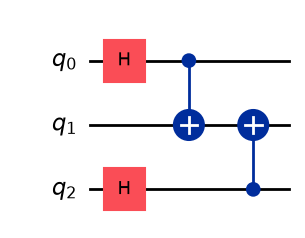

In [19]:
# 回路 A
qc_a = QuantumCircuit(4)
qc_a.h(0)
qc_a.h(1)
qc_a.cx(0, 2)
qc_a.cx(1, 3)
qc_a.cx(2, 3)
display(qc_a.draw("mpl"))

# 回路 A の予測した深さを your_answer_a に設定してください（整数）:
## ここにあなたのコードを追加してください ##
your_answer_a = 3

# 回路 B
qc_b = QuantumCircuit(3)
qc_b.h(0)
qc_b.cx(0, 1)
qc_b.h(2)
qc_b.cx(2, 1)
display(qc_b.draw("mpl"))

# 回路 B の予測した深さを your_answer_b に設定してください（整数）:
## ここにあなたのコードを追加してください ##
your_answer_b = 3
# 上の両方の予測を設定したら、次のセルを実行して確認し、その後 grader を実行してください。

In [20]:
# 解答を確認しましょう！
print("回路 A の深さ:", qc_a.depth())
print("回路 B の深さ:", qc_b.depth())

回路 A の深さ: 3
回路 B の深さ: 3


In [21]:
grade_lab1_ex2({"a": your_answer_a, "b": your_answer_b})

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 06:54:24,979: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! Both Circuit A and Circuit B have depth 3.
You scored 2 on this exercise.


<details>
<summary><b>クリックして解説を表示</b></summary>

**回路 A（深さ 3）:**
- 層1: H(0) と H(1)（異なる量子ビット、並列）
- 層2: CX(0,2) と CX(1,3)（異なる量子ビット、並列）
- 層3: CX(2,3)

**回路 B（深さ 3）:**
- 層1: H(0) と H(2)（異なる量子ビット、並列）
- 層2: CX(0,1)（H(0) を待たなければならない）
- 層3: CX(2,1)（前の CX と量子ビット1を共有するため、順次実行になる）

回路 B の描画では CX(0,1) と CX(2,1) が並列にできそうに見えるかもしれませんが、どちらも量子ビット1を使っていることに注目してください！
</details>

### 私たちの GHZ 回路の深さ

先ほど構築した2つの GHZ 構成の深さを確認しましょう。一方がもう一方より優れていると予想するかもしれませんが……

In [22]:
for n in [5, 10, 20]:
    fan_depth = ghz_fan(n).depth()
    chain_depth = ghz_chain(n).depth()
    print(f"n = {n:2d}:  fan depth = {fan_depth},  chain depth = {chain_depth}")

n =  5:  fan depth = 5,  chain depth = 5
n = 10:  fan depth = 10,  chain depth = 10
n = 20:  fan depth = 20,  chain depth = 20


どちらも **同じ深さ** です。両方とも $N$（H ゲートで1 + CX ゲートで $N-1$）です。なぜでしょうか。

- **ファンアウト**: すべての CX ゲートが量子ビット0を制御として共有するので、どれも並列に実行できません。
- **チェーン**: 各 CX は前の CX の結果に依存します（量子ビット $i$ がもつれてからでないと、量子ビット $i+1$ をもつれさせられません）。

どちらの構成も量子ビット数に対して *線形* です。100量子ビットなら100層のゲートで、ノイズの多いハードウェアには多すぎます。もっとうまくできるでしょうか。

### 深さを減らす: 真ん中から始める

ここで鍵となる洞察です。GHZ 状態は **対称的** です。すべての量子ビットが同じ重ね合わせに行き着きます。一方の端から構築し始める必要はないのです！

H ゲートを **真ん中** の量子ビットに置き、両方向へ *同時に* もつれを外側へ伸ばすと（左向きと右向きの2本のチェーンが並列に走る）、2つの半分が同時に進みます。これにより CX の深さがおよそ **半分** になります。

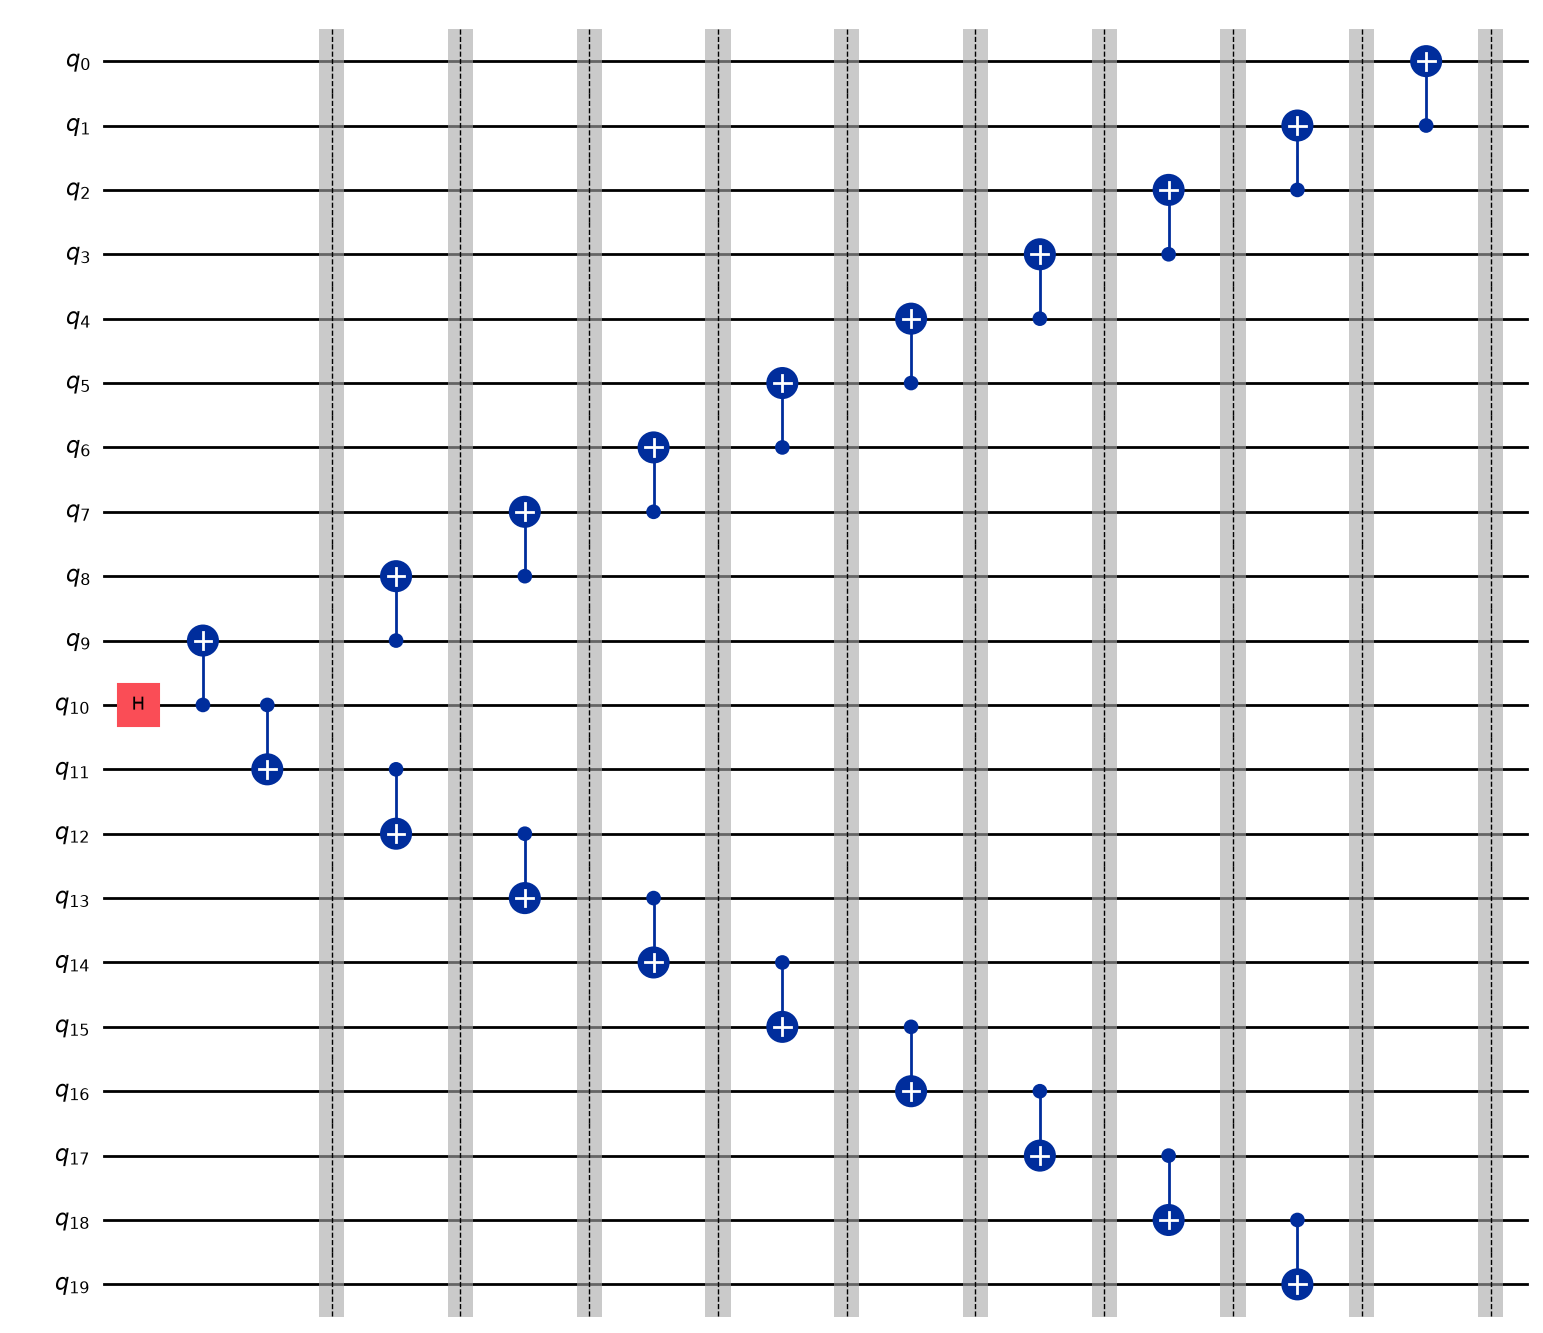

半分の深さの GHZ (20量子ビット): 深さ 11
線形の GHZ (20量子ビット):       深さ 20


In [23]:
def ghz_half_depth(n, add_barriers=False):
    """真ん中から始め、両方向へ外側に伸ばす GHZ。

    add_barriers=True を渡すと、外側への各ステップの後にバリアを挿入します。これにより
    回路の描画で並列な層が見えるようになります。バリアは1つの層として数えられるので、
    深さは常にバリアのない回路で測定してください。
    """
    qc = QuantumCircuit(n)
    mid = n // 2
    qc.h(mid)

    # 左と右へ同時に広げる
    for step in range(1, n):
        left = mid - step
        right = mid + step
        if left >= 0:
            qc.cx(left + 1, left)  # 左へ広げる
        if right < n:
            qc.cx(right - 1, right)  # 右へ広げる
        if add_barriers:
            qc.barrier()
        if left <= 0 and right >= n - 1:
            break
    return qc


# 並列な層が見やすいようにバリア付きで描画……
display(ghz_half_depth(20, add_barriers=True).draw("mpl"))

# ……ただし深さはバリアのない回路で測定する:
qc_half = ghz_half_depth(20)
print(f"半分の深さの GHZ (20量子ビット): 深さ {qc_half.depth()}")
print(f"線形の GHZ (20量子ビット):       深さ {ghz_chain(20).depth()}")

### さらに進める: 再帰的ファンアウト

半分にするトリックは、この考え方を一度だけ適用したものです。作業を2つの枝に分割しました。しかしこれを **再帰的に** 適用できます。真ん中の量子ビットがその左右の量子ビットをもつれさせたら、新しくもつれたそれらの量子ビットが *それぞれ* 新しい起点となって、もつれをさらに広げられるのです。

各層で、もつれていない隣接量子ビットを持つ、すでにもつれた各量子ビットが1つの CX を実行します。これにより、層ごとにもつれた量子ビットの数が **2倍** になります。

| 層 | 動作 | もつれた量子ビット |
|-------|--------|-----------------|
| 0 | 量子ビット0に H | 1 |
| 1 | CX(0,1) | 2 |
| 2 | CX(0,2) + CX(1,3) | 4 |
| 3 | CX(0,4) + CX(1,5) + CX(2,6) + CX(3,7) | 8 |
| 4 | CX(0,8) + CX(1,9) + … + CX(7,15) | 16 |

深さは $N$ ではなく $\lceil\log_2(N)\rceil + 1$ として増加します。**指数的な改善** です！

$N = 16$ の場合: 深さ = $\log_2(16) + 1 = 5$。

> **注:** 簡単のため、上の表は再帰的ファンアウトを真ん中ではなく **量子ビット0** から始めるものとして番号付けしています。どこから始めても $O(\log N)$ の深さのスケーリングは変わりません。重要なのは層ごとにもつれた量子ビットが倍になることです。下の演習3ではこの量子ビット0起点の番号付けを使います。

### 演習3: 16量子ビットの深さ5の GHZ 状態を構築する

**課題:** 再帰的ファンアウトを使って、深さがちょうど5の16量子ビット GHZ 回路を構築してください。

**戦略:** 各 CX 層で、すでにもつれた各量子ビットが新しい量子ビットを1つもつれさせるようにします。$k$ 回の CX 層の後には、$2^k$ 個のもつれた量子ビットになっているはずです。

**注:** この抽象的な（ハードウェアによらない）設定では、どの量子ビットも他のどの量子ビットにも接続できます。ハードウェアの制約はパート3で扱います。

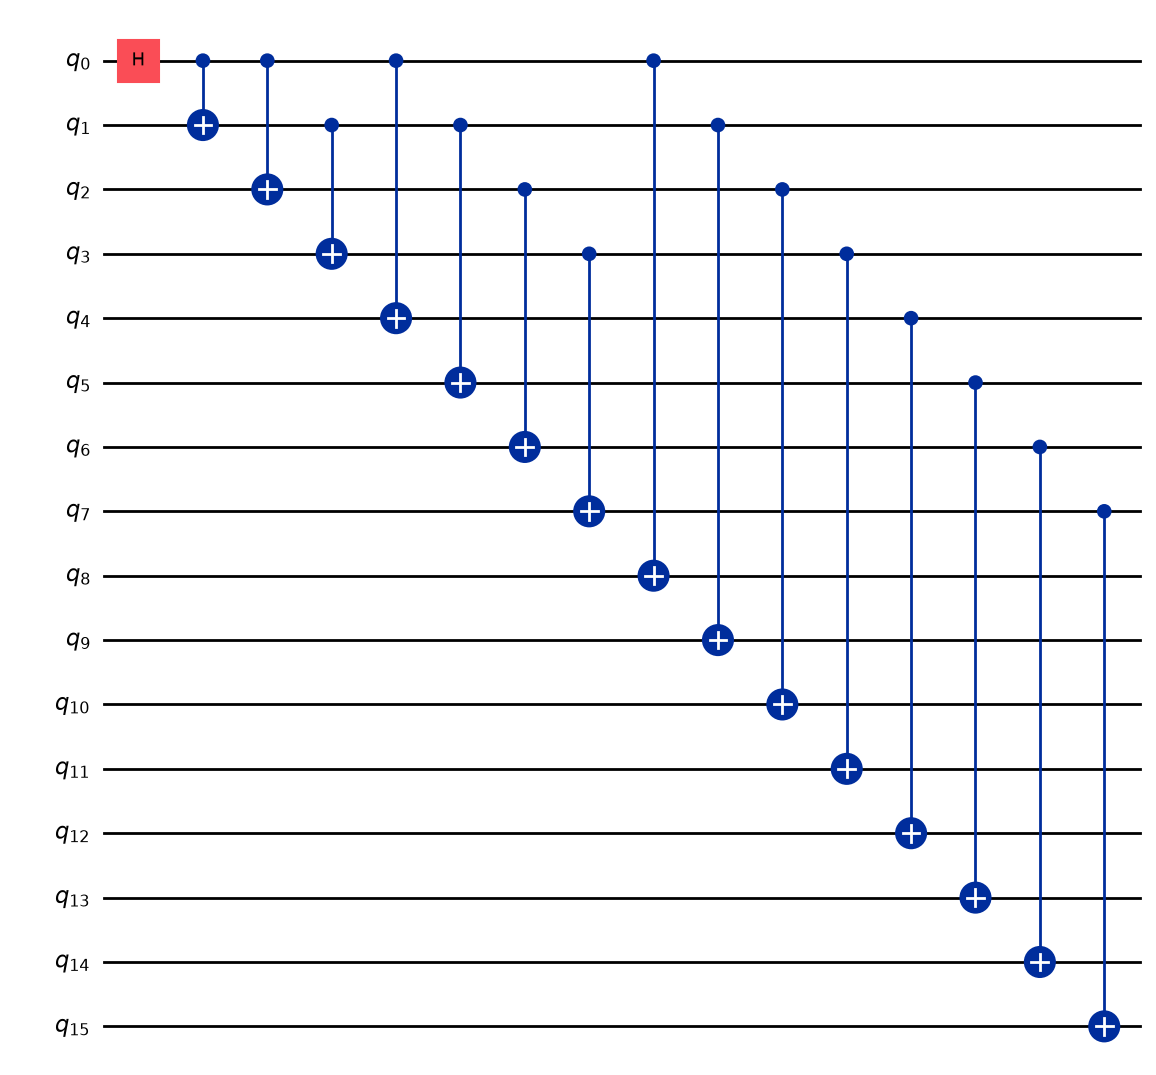

深さ: 5
成功 — 深さ5の有効な16量子ビット GHZ 状態です。


In [24]:
qc = QuantumCircuit(16)

# 層0: アダマール -- 1量子ビットを重ね合わせに
qc.h(0)

# 層1: 1個の CX ゲート → 2個のもつれた量子ビット
##  ここにあなたのコードを追加してください ##
qc.cx(0,1)

# 層2: 2個の CX ゲート → 4個のもつれた量子ビット
##  ここにあなたのコードを追加してください ##
qc.cx(0,2)
qc.cx(1,3)
# 層3: 4個の CX ゲート → 8個のもつれた量子ビット
##  ここにあなたのコードを追加してください ##
qc.cx(0,4)
qc.cx(1,5)
qc.cx(2,6)
qc.cx(3,7)
# 層4: 8個の CX ゲート → 16個のもつれた量子ビット
##  ここにあなたのコードを追加してください ##
for i in range(8):
    qc.cx(i,i+8)

# 確認
display(qc.draw("mpl"))
print("深さ:", qc.depth())
assert qc.depth() == 5, f"深さ5を期待しましたが、{qc.depth()} でした"

sv = Statevector(qc)
probs = np.abs(sv.data) ** 2
assert np.isclose(probs[0], 0.5) and np.isclose(probs[-1], 0.5), (
    "有効な GHZ 状態ではありません！"
)
print("成功 — 深さ5の有効な16量子ビット GHZ 状態です。")

In [25]:
grade_lab1_ex3(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 07:00:12,756: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! Depth-5 16-qubit GHZ (fidelity 1.0000).
You scored 1 on this exercise.


### パート2のまとめ

**達成した学習目標:**
- **回路の深さ**: 順次実行されるゲート層の数（少ないほど = ノイズが少ない）
- **GHZ 状態**: $N$ 量子ビットの量子もつれ $\frac{1}{\sqrt{2}}(|00\ldots0\rangle + |11\ldots1\rangle)$
- 線形の GHZ 回路（ファンアウトまたはチェーン）は深さ $N$
- **真ん中から始める** と深さが半分になる
- **再帰的ファンアウト** は深さ $\lceil\log_2(N)\rceil + 1$ を達成し、指数的に優れている

---

## パート3: トランスパイル <a id="part3"></a>

ここまで、抽象的な量子ビットと H や CX といったなじみのあるゲートを使って回路を構築してきました。しかし実際の量子ハードウェアには具体的な制約があります。

1. **限られたネイティブゲート**: プロセッサーは固定されたゲートの集合しかサポートしません。IBM Heron プロセッサーは $\{R_Z, \sqrt{X}, X, CZ\}$ を使います。H ゲートも CX ゲートもありません！
2. **限られた接続性**: すべての量子ビットのペアが物理的に接続されているわけではありません。接続されていない量子ビット間で2量子ビットゲートが必要な場合、追加の SWAP ゲートを挿入しなければなりません（それぞれ 3 個の CZ ゲートのコストがかかります）。
3. **物理量子ビットの割り当て**: あなたの抽象的な量子ビット0は、チップ上の特定の物理量子ビットに対応づけられなければなりません。

**トランスパイル** は、抽象的な回路をこれらすべての制約を尊重する回路へと変換する処理です。実際に見てみましょう。

In [26]:
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeTorino

# FakeTorino は133量子ビットの IBM Heron プロセッサーをシミュレートします
backend = FakeTorino()
print(f"Backend: {backend.name}")
print(f"Qubits: {backend.num_qubits}")
print(
    f"Native gates: {sorted(g for g in backend.operation_names if g not in ['reset', 'delay', 'measure', 'id', 'if_else', 'for_loop', 'switch_case'])}"
)

Backend: fake_torino
Qubits: 133
Native gates: ['cz', 'rz', 'sx', 'x']


小さく始めましょう。**5量子ビット** のチェーン GHZ をトランスパイルして、変換前後を読み取りやすくします。（サイズの変化に戸惑わないでください。パート2では20量子ビットまで上げました。演習7では再び64量子ビットの GHZ まで拡大します。）

元の回路:


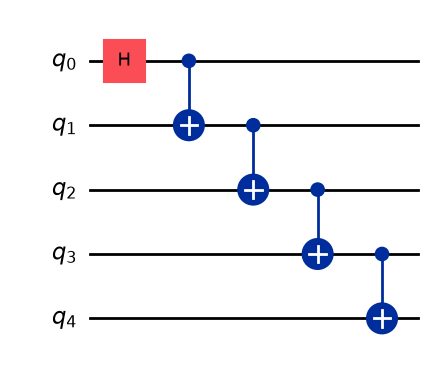


トランスパイル後の回路:


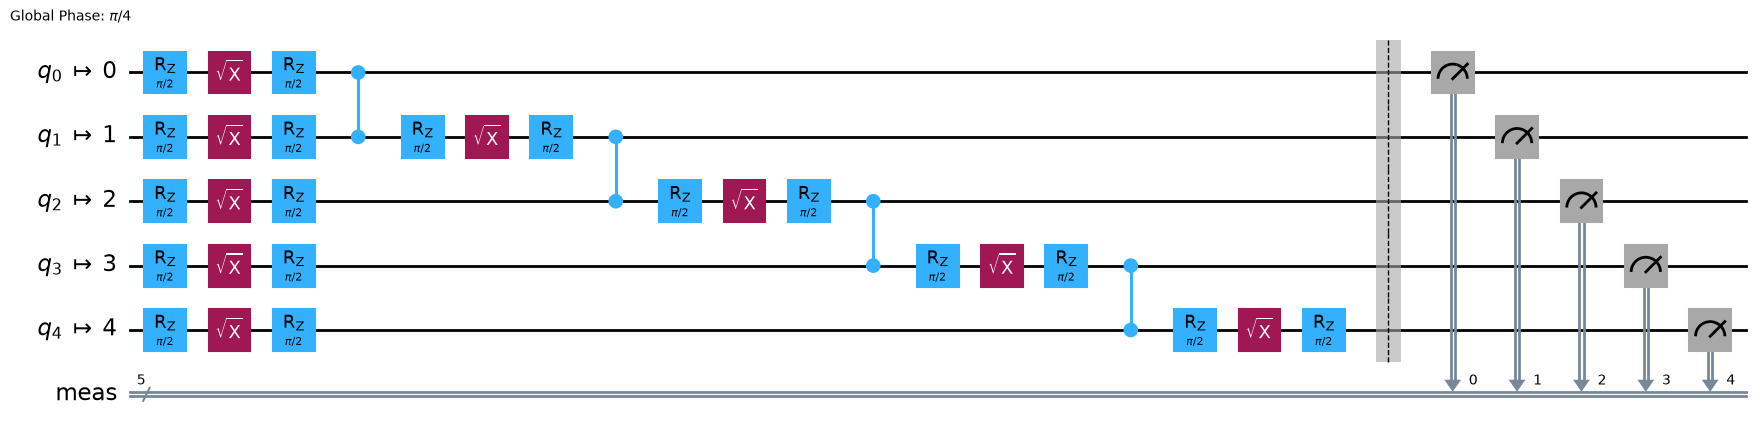


前: 深さ 5, ゲート {'cx': 4, 'h': 1}
後:  深さ 20, ゲート {'rz': 18, 'sx': 9, 'measure': 5, 'cz': 4, 'barrier': 1}


In [27]:
# シンプルな5量子ビットのチェーン GHZ 回路をトランスパイル
qc = ghz_chain(5)
print("元の回路:")
display(qc.draw("mpl"))

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_with_meas = qc.copy()
qc_with_meas.measure_all()
isa_qc = pm.run(qc_with_meas)

print("\nトランスパイル後の回路:")
display(isa_qc.draw("mpl", idle_wires=False))

print(f"\n前: 深さ {qc.depth()}, ゲート {dict(qc.count_ops())}")
print(f"後:  深さ {isa_qc.depth()}, ゲート {dict(isa_qc.count_ops())}")

#### 何が変わったのか？

トランスパイル後の回路を見てください。

- **H が消え**、$R_Z$ と $\sqrt{X}$ ゲート（ネイティブな単一量子ビットゲート）の組み合わせに置き換わっています
- **CX が消え**、単一量子ビットゲートに囲まれた CZ ゲートに置き換わっています
- **物理量子ビットの番号** が現れます。あなたの抽象的な量子ビットは、今や特定のハードウェア量子ビットに対応づけられています
- **深さが増加しました**: 各抽象ゲートが複数のネイティブゲートに展開されます

良い知らせ: トランスパイラーは5つの量子ビットすべてがチェーン状に物理的に接続されるレイアウトを見つけたので、**SWAP ゲートは不要でした**。いつもそうとは限りません！

### 寄り道: トポロジーを無視したらどうなる？

私たちのチェーン GHZ がきれいにトランスパイルされたのは、量子ビット 0-1-2-3-4 が Heron 上で物理的に接続されているからです。では、**同じ** 物理レイアウトで、代わりに **ファンアウト** パターンを使ったらどうなるでしょうか。量子ビット0は量子ビット1に接続されていますが、量子ビット2、3、4には接続されて **いません**。トランスパイラーは `CX(0, 2)`、`CX(0, 3)`、`CX(0, 4)` を実現するために何かをしなければなりません。

その解決策: **SWAP ゲートを挿入** して、量子ビット0の状態がその標的に隣接するまで、チェーンに沿って物理的にシャッフルします。各 SWAP は実機上で **3 個の CZ ゲート** に分解されます。これはトランスパイルがあなたの回路を *目に見えて* 書き換えている様子です。ゲート数と深さが跳ね上がるのを見てください。実際に見てみましょう。

> **測定についての注:** SWAP が論理量子ビットを異なる物理ワイヤーへ移すと、トランスパイラーは **測定も再ルーティング** して、各古典ビットが意図した量子ビットを記録し続けるようにします。この帳簿付けは自動的に処理されますが、そのためトランスパイル後の描画の測定部分が元の回路と1対1で一致しないことがあります。

直線 0-1-2-3-4 上のファンアウト GHZ（SWAP を見えたまま）:


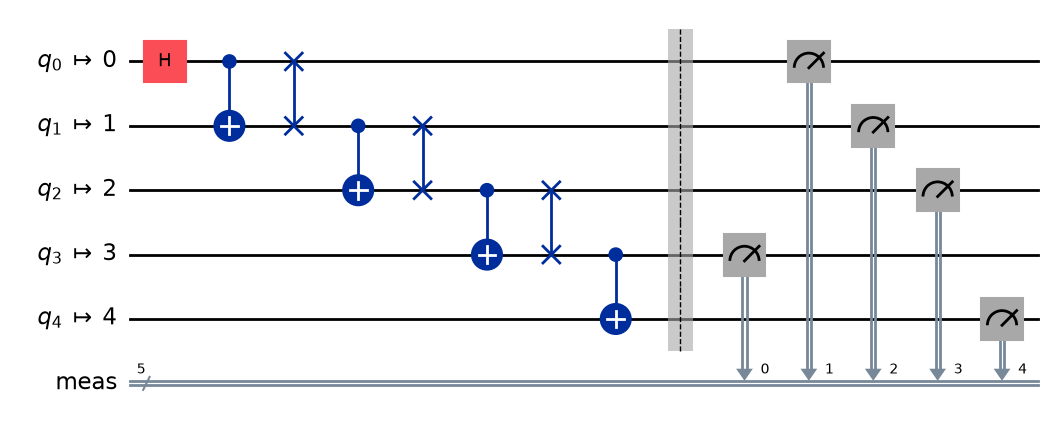

挿入された SWAP: 3
CX ゲート:       4
(最終的なネイティブ回路では、各 SWAP は 3 個の CZ ゲートになります。)

ネイティブゲートへ完全にトランスパイル: 深さ 25, CZ ゲート 10


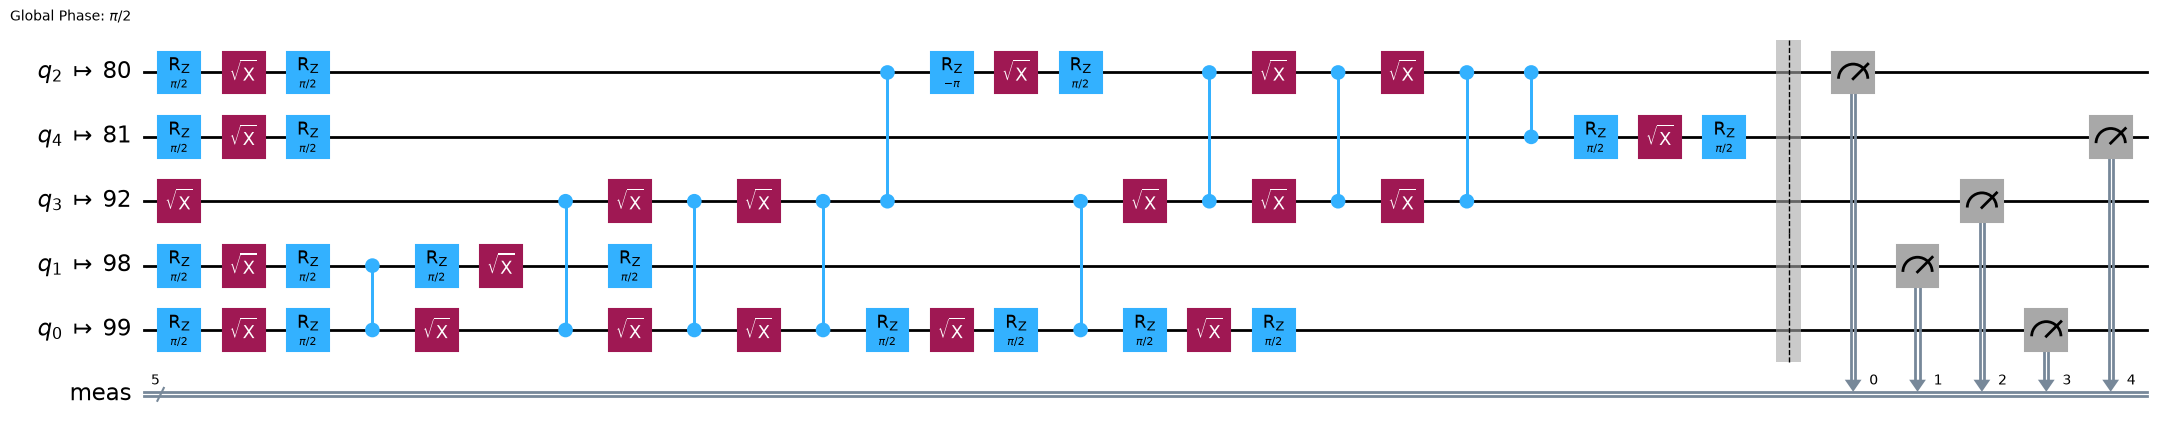

In [28]:
from qiskit import transpile

# 同じファンアウト GHZ、同じ物理レイアウト（Heron 上のチェーン 0-1-2-3-4）
qc_fan = ghz_fan(5)
qc_fan.measure_all()

# SWAP を見えたままにしてトランスパイル（まだネイティブゲートに分解しない）
isa_fan_swaps = transpile(
    qc_fan,
    coupling_map=backend.coupling_map,
    basis_gates=["h", "cx", "swap"],
    initial_layout=[0, 1, 2, 3, 4],
    optimization_level=1,
)

print("直線 0-1-2-3-4 上のファンアウト GHZ（SWAP を見えたまま）:")
display(isa_fan_swaps.draw("mpl", idle_wires=False))
print(f"挿入された SWAP: {isa_fan_swaps.count_ops().get('swap', 0)}")
print(f"CX ゲート:       {isa_fan_swaps.count_ops().get('cx', 0)}")
print("(最終的なネイティブ回路では、各 SWAP は 3 個の CZ ゲートになります。)")

# ここで完全にネイティブゲートへ分解 -- これが実際にハードウェアで動くものです:
isa_fan_native = pm.run(qc_fan)
print(
    f"\nネイティブゲートへ完全にトランスパイル: 深さ {isa_fan_native.depth()}, "
    f"CZ ゲート {isa_fan_native.count_ops().get('cz', 0)}"
)
display(isa_fan_native.draw("mpl", idle_wires=False, fold=-1))

### ブリッジゲートの等式

SWAP は非局所的な CX を扱う唯一の方法ではありません。**ブリッジゲート** と呼ばれる巧妙な回路の等式があり、チェーン `0 — 1 — 2` 上で最近接ゲートだけを使って、**状態を一切移動させずに** `CX(0, 2)` を実装します。

$$\text{CX}(0, 2) \;=\; \text{CX}(0, 1)\,\cdot\,\text{CX}(1, 2)\,\cdot\,\text{CX}(0, 1)\,\cdot\,\text{CX}(1, 2)$$

この順序での4つの最近接 CX ゲートは、1つの遠距離 `CX(0, 2)` と **まったく同じ** 変換を生成します。真ん中の量子ビットは「ブリッジ（橋）」として働きます。その状態は一時的に反転され、その後元に戻されて変化しないまま、もつれの作用が量子ビット0から量子ビット2へ伝播します。

ブリッジは、*1つ* の中間量子ビットを通して *1つ* の非局所 CX が必要なときに役立ちます。より複雑なルーティングでは、トランスパイラーは通常やはり SWAP を好みます。しかしこの等式は、非局所ゲートのコストを具体的に示します。このトリックを使っても、「無料の」非局所 CX は、局所的なものに比べて **4倍** の数の CX ゲートがかかります。

In [30]:
# ブリッジの等式を検証: CX(0, 2) == CX(0,1) CX(1,2) CX(0,1) CX(1,2)

# 直接: 1つの遠距離 CX（もつれの作用が見えるように量子ビット0に H を付ける）
qc_direct = QuantumCircuit(3)
qc_direct.h(0)
qc_direct.cx(0, 2)

# ブリッジ: 4つの最近接 CX ゲート
qc_bridge = QuantumCircuit(3)
qc_bridge.h(0)
qc_bridge.cx(0, 1)
qc_bridge.cx(1, 2)
qc_bridge.cx(0, 1)
qc_bridge.cx(1, 2)

sv_direct = Statevector(qc_direct)
sv_bridge = Statevector(qc_bridge)

print("直接の  CX(0, 2):", sv_direct)
print("ブリッジ形式:    ", sv_bridge)
print("状態は等しい？   ", sv_direct.equiv(sv_bridge))

直接の  CX(0, 2): Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))
ブリッジ形式:     Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))
状態は等しい？    True


### 演習4: ブリッジの等式を使って最近接 GHZ を構築する

以下はファンアウトパターンで構築した3量子ビット GHZ です。

```python
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)   # <-- この CX は 0-1-2 チェーン上では非局所です！
```

最後のゲート `CX(0, 2)` は、隣接する量子ビットだけが接続されているハードウェアでは直接実行できません。

**課題:** 同じ3量子ビット GHZ 状態を構築してください。ただし **ブリッジの等式** を使って `CX(0, 2)` を4つの最近接 CX ゲートに置き換えます。最終的な回路は `CX(0, 1)` と `CX(1, 2)` だけを使い、`CX(0, 2)` は決して使わないようにしてください。

終わったら、チェーン形式（`H(0); CX(0, 1); CX(1, 2)`）に比べて何個の CX ゲートを使ったかを見てください。その差が、ハードウェアがチェーンを望んでいるのにファンアウトの形にこだわることの本当のコストです。

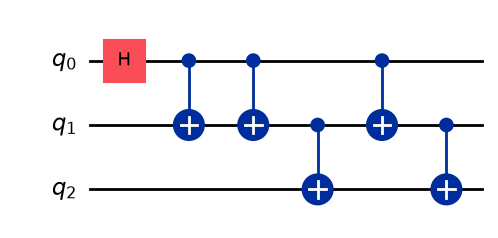

あなたの状態: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))
最近接の CX ゲートだけを使った有効な GHZ です（CX 合計 5 個）。


In [31]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)

##  ここにあなたのコードを追加してください: ブリッジの等式を使って非局所の CX(0, 2) を置き換える ##
qc.cx(0,1)
qc.cx(1,2)
qc.cx(0,1)
qc.cx(1,2)

## 確認
display(qc.draw("mpl"))
sv = Statevector(qc)
print("あなたの状態:", sv)

# 3量子ビットの GHZ 状態でなければなりません
probs = np.abs(sv.data) ** 2
assert np.isclose(probs[0], 0.5) and np.isclose(probs[-1], 0.5), (
    "有効な3量子ビット GHZ 状態ではありません！"
)

# 最近接の CX ゲートだけを使わなければなりません（量子ビットを飛ばさない）
non_local = []
for instr in qc.data:
    if instr.operation.name == "cx":
        q_indices = [qc.find_bit(q).index for q in instr.qubits]
        if abs(q_indices[0] - q_indices[1]) != 1:
            non_local.append(tuple(q_indices))
assert not non_local, f"最近接でない CX が見つかりました: {non_local}"

print(f"最近接の CX ゲートだけを使った有効な GHZ です（CX 合計 {qc.count_ops().get('cx', 0)} 個）。")

In [32]:
grade_lab1_ex4(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 07:08:44,580: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! 3-qubit GHZ using only nearest-neighbor CX (fidelity 1.0000).
You scored 1 on this exercise.


<details>
<summary><b>クリックして解答を表示</b></summary>

```python
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
# CX(0, 2) を置き換えるブリッジの等式: 4つの最近接 CX ゲート
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(0, 1)
qc.cx(1, 2)
```

これは機能しますが、元の `CX(0, 1)` とブリッジ由来の最初の `CX(0, 1)` が隣り合っていること、そして `CX(0, 1) · CX(0, 1) = I`（どの CX も自分自身の逆）であることに注目してください。したがってそれらを打ち消せて、次が残ります。

```python
qc.h(0)
qc.cx(1, 2)
qc.cx(0, 1)
qc.cx(1, 2)
```

**CX 3個。** チェーン形式 `H(0); CX(0,1); CX(1,2)` が **2個** を使うのと比べてください。簡約化しても、最近接チップ上でファンアウトの形にこだわると、非局所のホップごとに CX が1個余分にかかります。より長いチェーンや距離の大きい CX では、このオーバーヘッドは急速に増大します。だからこそ、最初からトポロジーを意識した回路を設計すること（パート3の残り）が本当の勝ち筋なのです。
</details>

### 演習5: 直線上の効率的な5量子ビット GHZ

FakeTorino 上の物理量子ビット 0〜4 はチェーンを形成します: 0-1-2-3-4。この接続性を尊重し、深さを最小化する GHZ 回路を構築しましょう。

**課題:** 真ん中の量子ビットから始めて、抽象的な深さ **4** の5量子ビット GHZ 回路を構築してください。

<details>
<summary><b>ヒント</b></summary>

パート2の「真ん中から始める」トリックを思い出してください！真ん中の量子ビットに H を置き、両端に向かって外側へ伸ばしましょう。
</details>

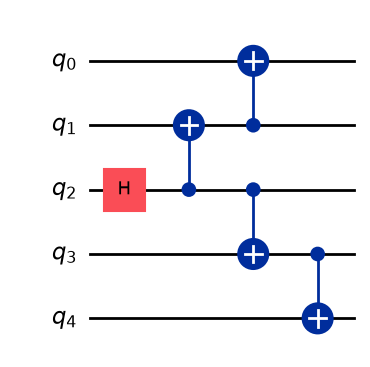

抽象的な深さ: 4
トランスパイル後の深さ: 13
CZ ゲート: 4


In [33]:
qc = QuantumCircuit(5)

##  ここにあなたのコードを追加してください: 真ん中から始めて深さ4の GHZ を構築 ##
qc.h(2)
qc.cx(2,1)
qc.cx(2,3)
qc.cx(1,0)
qc.cx(3,4)

# 確認
display(qc.draw("mpl"))
print("抽象的な深さ:", qc.depth())
assert qc.depth() == 4, f"深さ4を期待しましたが、{qc.depth()} でした"

# 直線の部分グラフ 0-1-2-3-4 向けにトランスパイル
qc_m = qc.copy()
qc_m.measure_all()
pm = generate_preset_pass_manager(
    optimization_level=1, backend=backend, initial_layout=[0, 1, 2, 3, 4]
)
isa_qc = pm.run(qc_m)
print(f"トランスパイル後の深さ: {isa_qc.depth()}")
print(f"CZ ゲート: {isa_qc.count_ops().get('cz', 0)}")

In [34]:
grade_lab1_ex5(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 07:13:40,877: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! Depth-4 5-qubit GHZ (fidelity 1.0000).
You scored 1 on this exercise.


### ハードウェアのトポロジー: ヘビーヘックス

FakeTorino は **ヘビーヘックス**（heavy-hex）接続性を持つ **Heron プロセッサー** をモデル化します。133個の量子ビットは特徴的なパターンで配置されています。

- 各行を横切って量子ビットの **水平チェーン** が走る
- **垂直のブリッジ量子ビット** がずれた位置で行同士を接続する
- ほとんどの量子ビットは **次数2**（隣接が2つ）
- **分岐（ジャンクション）量子ビット** は **次数3**（隣接が3つ）を持つ。これらが分岐点

このトポロジーは全結合では *ありません*。隣接しない量子ビット間の2量子ビットゲートには SWAP ゲートが必要で、深さが劇的に増加します。ヘビーヘックス向けに効率的な回路を構築するとは、接続性に *逆らう* のではなく、*沿って* 作業することを意味します。

FakeTorino のカップリングマップの一部を可視化して、その構造を見てみましょう。

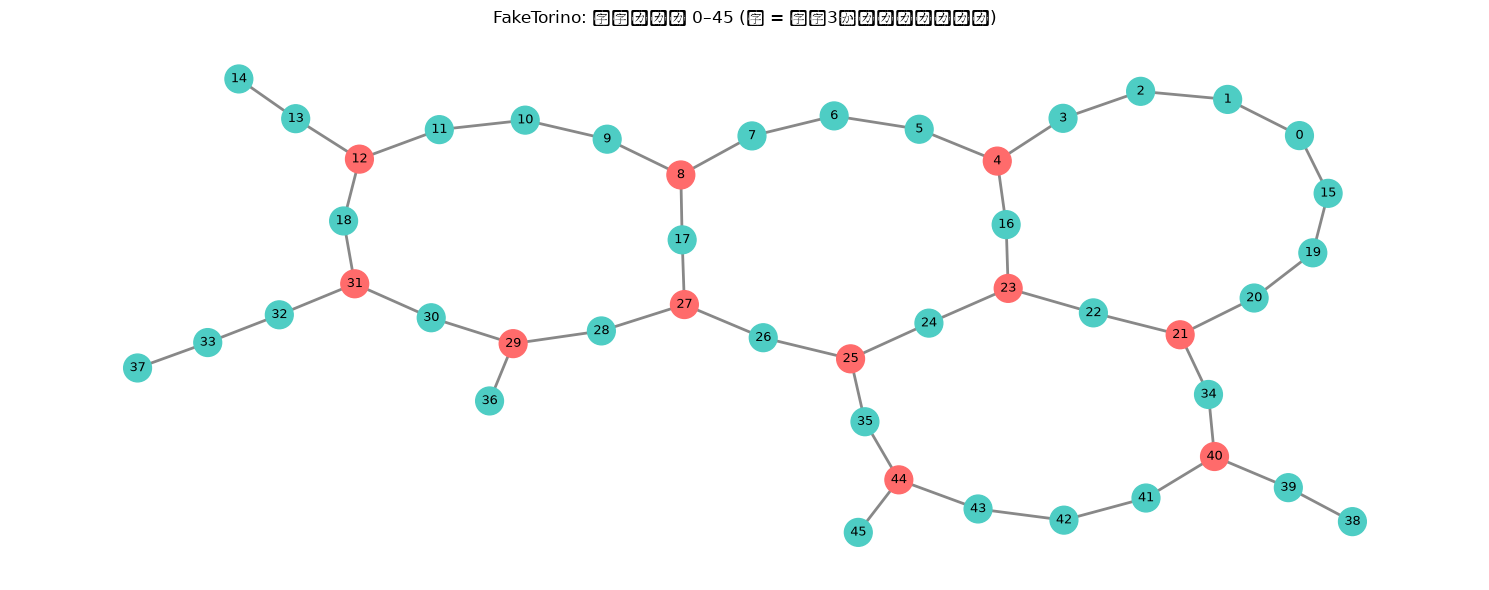

次数3のジャンクション (量子ビット 0-45): [4, 8, 12, 21, 23, 25, 27, 29, 31, 40, 44]


In [35]:
# FakeTorino の一部について、ヘビーヘックス接続性を可視化
import networkx as nx

cm = backend.coupling_map
# 演習6の T 字ジャンクションを示すのに十分な量子ビットを含める: 量子ビット25の3番目の
# 隣接は量子ビット35（35-44 が垂直の脚を形成）で、これは最初の2行より先にあります。
# そのため33で止めず、量子ビット0-45を描画します。
sub_qubits = set(range(46))

G = nx.Graph()
for q in sub_qubits:
    G.add_node(q)
for q in sub_qubits:
    for nb in cm.neighbors(q):
        if nb in sub_qubits:
            G.add_edge(q, nb)

# 次数3のジャンクションを特定
junctions = [q for q in sub_qubits if G.degree(q) == 3]
colors = ["#ff6b6b" if q in junctions else "#4ecdc4" for q in G.nodes()]

fig, ax = plt.subplots(figsize=(15, 6))
pos = nx.kamada_kawai_layout(G)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=400,
    font_size=9,
    node_color=colors,
    edge_color="#888",
    width=2,
    ax=ax,
)
ax.set_title("FakeTorino: 量子ビット 0–45 (赤 = 次数3のジャンクション)")
plt.tight_layout()
display(fig)
plt.close(fig)

print("次数3のジャンクション (量子ビット 0-45):", sorted(junctions))

### 演習6: ヘビーヘックス部分グラフ上の7量子ビット GHZ

FakeTorino のこの T 字型の部分グラフを考えます。

```
23 -- 24 -- 25 -- 26 -- 27
            |
           35
            |
           44
```

量子ビット25は **次数3のジャンクション** です。量子ビット24、26、35に接続しています。上でプロットしたヘビーヘックストポロジーのグラフの中に、まさにこの T 字型（量子ビット25とその3つの隣接、そして 25–35–44 の脚）を見つけられます。

**課題:** この部分グラフ上に、**可能な限り最小の深さ** で7量子ビット GHZ 回路を構築してください。

<details>
<summary><b>ヒント</b></summary>

- どの量子ビットから始めるべきでしょうか？（分岐点がどこにあるかを考えましょう！）
- 覚えておいてください: 1つの量子ビットは1つの層につき1つの CX ゲートにしか参加できません。
- 抽象的な量子ビットを次のように対応づけます: 0→q23、1→q24、2→q25、3→q26、4→q27、5→q35、6→q44。
</details>

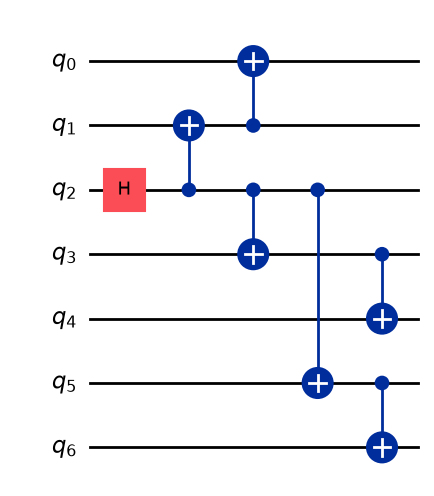

抽象的な深さ: 5
トランスパイル後の深さ: 14
CZ ゲート: 6


In [36]:
# 部分グラフの隣接関係（抽象的な量子ビット番号）:
# 0(q23) -- 1(q24) -- 2(q25) -- 3(q26) -- 4(q27)
#                      |
#                    5(q35)
#                      |
#                    6(q44)

qc = QuantumCircuit(7)

##  ここにあなたのコードを追加してください: 最適な量子ビットから始めて GHZ を構築 ##
qc.h(2)
qc.cx(2,1)
qc.cx(2,3)
qc.cx(2,5)
qc.cx(1,0)
qc.cx(3,4)
qc.cx(5,6)

# 確認
display(qc.draw("mpl"))
print("抽象的な深さ:", qc.depth())

# 物理レイアウトでトランスパイル
qc_m = qc.copy()
qc_m.measure_all()
pm = generate_preset_pass_manager(
    optimization_level=1, backend=backend, initial_layout=[23, 24, 25, 26, 27, 35, 44]
)
isa_qc = pm.run(qc_m)
print(f"トランスパイル後の深さ: {isa_qc.depth()}")
print(f"CZ ゲート: {isa_qc.count_ops().get('cz', 0)}")

In [37]:
grade_lab1_ex6(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 07:17:17,263: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! Depth-5 7-qubit GHZ on the T-shape (fidelity 1.0000). Optimal depth achieved.
You scored 2 on this exercise.


### 演習7: 最終チャレンジ — 64量子ビット GHZ

さて、すべてを組み合わせましょう。あなたの課題は、**64量子ビット**（FakeTorino の量子ビット 0〜63）向けに効率的な GHZ 状態を構築し、トランスパイルすることです。

<details>
<summary><b>初めて？「BFS 全域木」とは何で、なぜ使うのか</b></summary>

**全域木（スパニングツリー）** は、部分グラフのすべての量子ビットをループなしで接続する辺の集合です。**幅優先探索（BFS）** は、選んだ *中心* 量子ビットから始めて、外側へリング状に探索することで全域木を構築します。まずそのすべての隣接（距離1）、次に *それらの* 未訪問の隣接（距離2）、というように進みます。

これが回路の深さにとってなぜ重要か: 各量子ビットをその BFS の *親* ともつれさせると、GHZ 回路の深さは本質的に木の中の **根から葉までの最長距離** になります。よく中心に位置する量子ビットから始めると、その距離——したがって深さ——をハードウェアグラフが許す限り小さく保てます。（これはパート2の「真ん中から始める」という考え方を、直線から任意のグラフへ一般化したものです。）

背景: [幅優先探索](https://en.wikipedia.org/wiki/Breadth-first_search) · [`CouplingMap`](https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.CouplingMap)。
</details>

**戦略:**
1. バックエンドのカップリングマップを使って量子ビット 0〜63 の接続性を調べる
2. よく選ばれた中心量子ビットから BFS（幅優先探索）で **全域木** を構築する
3. 木に沿って層ごとにもつれさせて GHZ 回路を構成する
4. トランスパイルして、素朴な線形 GHZ と深さを比較する

**役立つ情報:**
- 0〜63 の部分グラフで最適な中心量子ビットは **量子ビット25** です（他のどの量子ビットへの最大距離も最小化します）
- `backend.coupling_map.neighbors(q)` は量子ビット $q$ の隣接を返します
- BFS 木は次のセルであなたのために構築されます。あなたの仕事は、各量子ビットからその親へのもつれ CX を追加する1行だけです。

In [38]:
# ヘルパー: 64量子ビットの部分グラフ内の次数3ジャンクションを表示
sub = set(range(64))
print("量子ビット 0-63 内の次数3ジャンクション:")
for q in sorted(sub):
    nbs = [nb for nb in cm.neighbors(q) if nb in sub]
    if len(nbs) >= 3:
        print(f"  量子ビット {q}: 隣接 {sorted(nbs)}")

量子ビット 0-63 内の次数3ジャンクション:
  量子ビット 4: 隣接 [3, 5, 16]
  量子ビット 8: 隣接 [7, 9, 17]
  量子ビット 12: 隣接 [11, 13, 18]
  量子ビット 21: 隣接 [20, 22, 34]
  量子ビット 23: 隣接 [16, 22, 24]
  量子ビット 25: 隣接 [24, 26, 35]
  量子ビット 27: 隣接 [17, 26, 28]
  量子ビット 29: 隣接 [28, 30, 36]
  量子ビット 31: 隣接 [18, 30, 32]
  量子ビット 40: 隣接 [34, 39, 41]
  量子ビット 42: 隣接 [41, 43, 54]
  量子ビット 44: 隣接 [35, 43, 45]
  量子ビット 46: 隣接 [45, 47, 55]
  量子ビット 48: 隣接 [36, 47, 49]
  量子ビット 50: 隣接 [49, 51, 56]
  量子ビット 61: 隣接 [54, 60, 62]


In [39]:
from collections import deque

n = 64
sub = set(range(n))

# ステップ1: 中心量子ビットから BFS で全域木を構築
center = 25  # 最適な中心 -- これを変えて深さがどう変わるか見てみましょう！

parent = {center: None}
bfs_depth = {center: 0}
queue = deque([center])

while queue:
    node = queue.popleft()
    for nb in sorted(cm.neighbors(node)):
        if nb in sub and nb not in parent:
            parent[nb] = node
            bfs_depth[nb] = bfs_depth[node] + 1
            queue.append(nb)

print(f"量子ビット {center} からの BFS: {len(parent)} 個の量子ビットに到達")
print(f"最大 BFS 深さ: {max(bfs_depth.values())}")

# ステップ2: BFS 木に沿って層ごとに GHZ 回路を構築
qc = QuantumCircuit(n)
qc.h(center)

max_d = max(bfs_depth.values())
for d in range(1, max_d + 1):
    for q in range(n):
        if q in bfs_depth and bfs_depth[q] == d:
            # ===>  ここにあなたのコードを1行追加してください <===
            # 量子ビット q をその BFS の親 parent[q] と、単一の CX でもつれさせる。
            # (下の `pass` をそのゲートに置き換えてください。)
            ##  ここにあなたのコードを追加してください: parent[q] から q への CX を追加 ##
            qc.cx(parent[q],q)
            pass

qc.measure_all()
print(f"\nあなたの GHZ の抽象的な深さ: {qc.depth() - 1}")  # 測定層の分 -1

# ステップ3: トランスパイルして比較
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_qc = pm.run(qc)
print(f"あなたの GHZ のトランスパイル後の深さ: {isa_qc.depth()}")
print(f"あなたの GHZ の CZ ゲート: {isa_qc.count_ops().get('cz', 0)}")

# 素朴な比較
qc_naive = ghz_chain(n)
qc_naive.measure_all()
isa_naive = pm.run(qc_naive)
print(f"\n素朴なチェーンのトランスパイル後の深さ: {isa_naive.depth()}")
print(f"素朴なチェーンの CZ ゲート: {isa_naive.count_ops().get('cz', 0)}")

量子ビット 25 からの BFS: 64 個の量子ビットに到達
最大 BFS 深さ: 10

あなたの GHZ の抽象的な深さ: 14
あなたの GHZ のトランスパイル後の深さ: 47
あなたの GHZ の CZ ゲート: 63

素朴なチェーンのトランスパイル後の深さ: 256
素朴なチェーンの CZ ゲート: 63


In [40]:
grade_lab1_ex7(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-18 07:29:58,898: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: QC2026S-dedicated. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Correct! 64-qubit GHZ on a spanning tree from q25 (abstract depth 14).
You scored 2 on this exercise.


### パート3のまとめ

**達成した学習目標:**
- **トランスパイル** は抽象的な回路をハードウェアネイティブなものへ変換する（ゲート分解 + 量子ビットルーティング + レイアウト）
- Heron プロセッサーは $\{R_Z, \sqrt{X}, X, CZ\}$ を使う（H も CX もない）
- **ヘビーヘックストポロジー**: 次数2のチェーン量子ビットと次数3のジャンクション量子ビット
- SWAP ゲート（隣接しない量子ビットに必要）はそれぞれ 3 個の CZ のコストがかかるので、トポロジーを意識した回路を設計して避ける
- **BFS 全域木**: 任意のハードウェアグラフ上で効率的な GHZ 回路を構築する体系的な方法

---

## パート4: ノイズ入りシミュレーターで実行する <a id="part4"></a>

では、回路の深さがノイズの多いプロセッサー上の結果に実際どう影響するかを見てみましょう。**FakeTorino**——実際の Torino チップの誤り率と接続性を再現する *ローカルの* ノイズ入りシミュレーター——を使って、効率的な GHZ 回路と素朴なものを比較します。この節のすべては **ローカルで** 動作するので、**IBM Quantum のランタイム時間（分）は消費しません**。最後のコードセルでは、実機バックエンドに切り替える方法を示します。

これは **Qiskit パターン** のワークフローに従います。
1. **マップ (Map)**: 問題に対する抽象的な回路を設計する
2. **最適化 (Optimize)**: 対象バックエンド向けにトランスパイルする
3. **実行 (Execute)**: `SamplerV2` を使って実行する
4. **後処理 (Post-process)**: 測定結果を分析する

In [41]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

# FakeTorino のノイズモデルと接続性を使ってノイズ入りシミュレーターを構築
aer_backend = AerSimulator.from_backend(FakeTorino())
sampler = SamplerV2(aer_backend)
print(
    f"実行準備完了: {aer_backend.name} ({aer_backend.num_qubits} qubits, ノイズ入りシミュレーション)"
)

# このローカルのノイズ入りシミュレーターの代わりに実機ハードウェアで実行するには、
# 実機バックエンドに差し替えます（これは IBM Quantum のランタイム時間を消費し、保存済みのアカウントが必要です）:
#
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService()
# real_backend = service.least_busy(operational=True, simulator=False)
# sampler = SamplerV2(real_backend)

実行準備完了: aer_simulator_from(fake_torino) (133 qubits, ノイズ入りシミュレーション)


### 実験

2つの15量子ビット GHZ 回路（FakeTorino の行0、量子ビット 0〜14 を使用）を比較します。

1. **素朴（ファンアウト）**: 量子ビット0に H、次に CX(0,1)、CX(0,2)、…、CX(0,14)。これはハードウェアの接続性と一致 *しません*。量子ビット0は他のほとんどの量子ビットに接続されていないので、トランスパイラーは多くの SWAP ゲートを挿入しなければなりません。

2. **効率的（トポロジーを意識）**: 真ん中（量子ビット7）から始め、物理チェーンに沿って両方向にファンアウトします。これはハードウェアと一致 *する* ので、SWAP は不要です。

私たちの最適化理論が正しければ、効率的な回路のほうが著しく高い忠実度を持つはずです。

In [42]:
n = 15

# 素朴: 量子ビット0からのファンアウト（ハードウェアには不向き！）
qc_naive = QuantumCircuit(n)
qc_naive.h(0)
for i in range(1, n):
    qc_naive.cx(0, i)
qc_naive.measure_all()

# 効率的: 物理チェーンに沿って真ん中からファン
qc_eff = QuantumCircuit(n)
mid = n // 2  # 量子ビット7
qc_eff.h(mid)
for step in range(1, n):
    left = mid - step
    right = mid + step
    if left >= 0:
        qc_eff.cx(left + 1, left)
    if right < n:
        qc_eff.cx(right - 1, right)
    if left <= 0 and right >= n - 1:
        break
qc_eff.measure_all()

# 実行のためネイティブゲートへ完全にトランスパイル
pm = generate_preset_pass_manager(
    optimization_level=1, backend=backend, initial_layout=list(range(n))
)
isa_naive = pm.run(qc_naive)
isa_eff = pm.run(qc_eff)

# SWAP を見えたまま保つ並列トランスパイル（診断用のカウントのみ）
isa_naive_swaps = transpile(
    qc_naive,
    coupling_map=backend.coupling_map,
    basis_gates=["h", "cx", "swap"],
    initial_layout=list(range(n)),
    optimization_level=1,
)
isa_eff_swaps = transpile(
    qc_eff,
    coupling_map=backend.coupling_map,
    basis_gates=["h", "cx", "swap"],
    initial_layout=list(range(n)),
    optimization_level=1,
)
naive_swaps = isa_naive_swaps.count_ops().get("swap", 0)
eff_swaps = isa_eff_swaps.count_ops().get("swap", 0)

print("=== 回路の比較 ===")
print(
    f"素朴:     挿入された SWAP = {naive_swaps:>2},  "
    f"トランスパイル後の深さ = {isa_naive.depth():>4},  "
    f"CZ ゲート = {isa_naive.count_ops().get('cz', 0)}"
)
print(
    f"効率的: 挿入された SWAP = {eff_swaps:>2},  "
    f"トランスパイル後の深さ = {isa_eff.depth():>4},  "
    f"CZ ゲート = {isa_eff.count_ops().get('cz', 0)}"
)
print("\n(各 SWAP は約3個の CZ ゲートになります。だから素朴な CZ 数がこれほど急速に増えるのです。)")

=== 回路の比較 ===
素朴:     挿入された SWAP = 13,  トランスパイル後の深さ =  125,  CZ ゲート = 53
効率的: 挿入された SWAP =  0,  トランスパイル後の深さ =   33,  CZ ゲート = 14

(各 SWAP は約3個の CZ ゲートになります。だから素朴な CZ 数がこれほど急速に増えるのです。)


In [43]:
# 両方の回路をノイズ入りシミュレーターで実行。
# SHOTS はサンプリング回数を制御します。8192 が理想ですが、無料の Colab/qBraid
# セッションではタイムアウトすることがあります。必要なら下げてください（ここでは 1024-2048 で十分です）。
SHOTS = 2048

job = sampler.run([isa_naive, isa_eff], shots=SHOTS)
result = job.result()

counts_naive = result[0].data.meas.get_counts()
counts_eff = result[1].data.meas.get_counts()
print("実行が完了しました！")
print(f"素朴:     {sum(counts_naive.values())} ショット")
print(f"効率的: {sum(counts_eff.values())} ショット")

実行が完了しました！
素朴:     2048 ショット
効率的: 2048 ショット


In [44]:
# GHZ 忠実度を計算: |00...0⟩ または |11...1⟩ に入ったショットの割合
def ghz_fidelity(counts, n):
    total = sum(counts.values())
    correct = counts.get("0" * n, 0) + counts.get("1" * n, 0)
    return correct / total


fid_naive = ghz_fidelity(counts_naive, n)
fid_eff = ghz_fidelity(counts_eff, n)

print(f"素朴な GHZ の忠実度:     {fid_naive:.4f}")
print(f"効率的な GHZ の忠実度: {fid_eff:.4f}")
if fid_eff > fid_naive:
    improvement = (fid_eff - fid_naive) / fid_naive * 100
    print(f"改善: {improvement:.1f}%")

素朴な GHZ の忠実度:     0.3906
効率的な GHZ の忠実度: 0.4795
改善: 22.8%


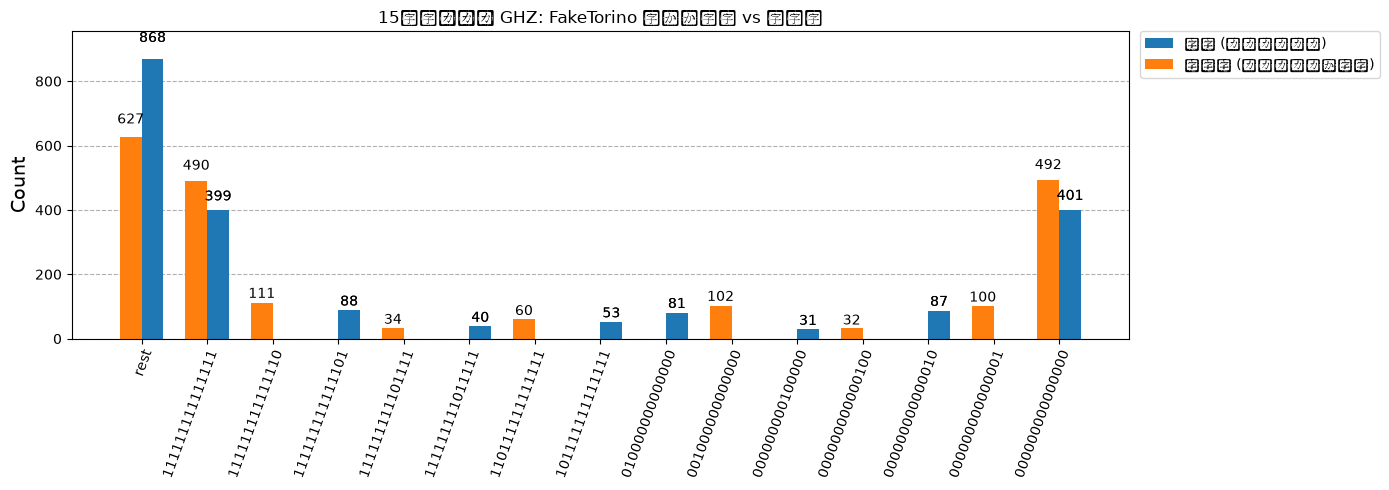

In [45]:
# 可視化: 測定結果を並べたヒストグラム
display(
    plot_histogram(
        [counts_naive, counts_eff],
        legend=["素朴 (ファンアウト)", "効率的 (トポロジーを意識)"],
        number_to_keep=8,
        sort="desc",
        title=f"{n}量子ビット GHZ: FakeTorino 上での素朴 vs 効率的",
        figsize=(14, 5),
    )
)

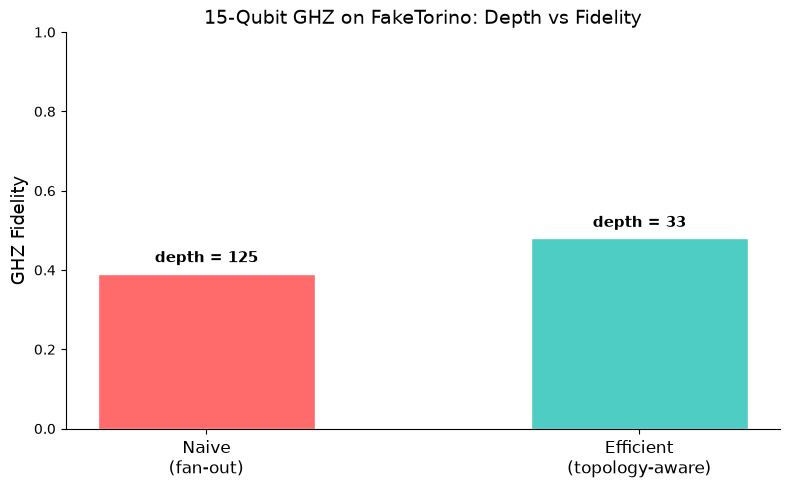

In [46]:
# まとめの棒グラフ: 忠実度 vs トランスパイル後の深さ
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Naive\n(fan-out)", "Efficient\n(topology-aware)"]
fidelities = [fid_naive, fid_eff]
depths = [isa_naive.depth(), isa_eff.depth()]
colors = ["#ff6b6b", "#4ecdc4"]

bars = ax.bar(
    range(len(labels)), fidelities, color=colors, width=0.5, edgecolor="white"
)
ax.set_ylabel("GHZ Fidelity", fontsize=13)
ax.set_title(f"{n}-Qubit GHZ on FakeTorino: Depth vs Fidelity", fontsize=14)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=12)

# 棒にトランスパイル後の深さを注記
for bar, d, f in zip(bars, depths, fidelities):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.02,
        f"depth = {d}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylim(0, 1.0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
display(fig)
plt.close(fig)

### 何が見えるか？

効率的な回路は、トランスパイル後の深さが小さく2量子ビットゲートも少ないため、ノイズ入りシミュレーター上で著しく高い忠実度を達成します。パターンは明白です。

- **CZ ゲートが少ない** → 2量子ビット誤差の発生源が少ない
- **深さが小さい** → 量子ビットがデコヒーレンスする時間が短い
- **SWAP ゲートがない** → ルーティングによる不要なオーバーヘッドがない

> **絶対的な数値に驚かないでください。** ノイズの多いハードウェア上の15量子ビット GHZ 状態は本当に難しいので、ここでの生の忠実度はしばしば **0.4〜0.6** の範囲になります。教科書で期待するような約0.99ではありません。2量子ビットゲートはそれぞれわずかに誤差を加え、その数がとても多いのです。この実験で重要なのは、素朴なものに対する効率的な回路の **相対的な** 改善です。その差こそが要点のすべてです。

実機ハードウェアでは、差はさらに劇的になります。これは **回路の最適化が単なる学術的な練習ではない** ことを示しています。それはあなたの量子計算の品質に直接影響するのです。

### 先を見据えて: Lab 2

Lab 2 では、新しい IBM **Nighthawk** プロセッサーと、（このラボで扱ってきたアーキテクチャーである）**Heron** プロセッサーを比較します。この2つは異なる接続性パターンを持ちます。Heron はヘビーヘックスを使う一方、Nighthawk は量子ビットあたりの隣接がより多い、より密なグラフを持ちます。こうしたアーキテクチャーの違いは、回路の性能に直接影響します。

ここで身につけたスキル（効率的な GHZ 状態の構築、深さの理解、ヘビーヘックストポロジーでの作業）は、GHZ 回路を使って2つのプロセッサーをベンチマークし比較する Lab 2 に直接つながります。

Lab 2 でお会いしましょう！ 🚀

---

## Lab 1 完了: 最終まとめ

**学んだこと:**

| 概念 | 要点 |
|---------|-------------|
| **X, H, CX ゲート** | 量子回路の構成要素 |
| **重ね合わせ** | H ゲートが $\frac{1}{\sqrt{2}}(\lvert 0\rangle + \lvert 1\rangle)$ を生成 |
| **量子もつれ** | CX + 重ね合わせが相関した量子ビットのペアを生成 |
| **ベル状態と GHZ 状態** | 2量子ビットと N 量子ビットの量子もつれ |
| **回路の深さ** | 順次実行されるゲート層の数。少ないほど = ノイズが少ない |
| **再帰的ファンアウト** | GHZ を $O(N)$ ではなく $O(\log N)$ の深さで |
| **トランスパイル** | 抽象的 → ハードウェアネイティブな回路 |
| **ヘビーヘックストポロジー** | 次数2のチェーン + 次数3のジャンクション |
| **トポロジーを意識した設計** | ハードウェアの接続性に沿って SWAP を避ける |
| **ノイズ入り実行** | 深さが小さい → 実機での忠実度が高い |

# 追加情報

**作成者:** James Weaver

**バージョン:** 1.0.0